## Preliminary Thoughts
- Our project will be focused on weather conditions during NFL games and creating an index that will display how ideal the current conditions are for playing.
- Weather Conditions that will be focused on:
  - Rain
  - Snow
  - Temperature
  - Wind
  - Lightning
  - Wind Chill
  - Heat Index 

## Create a Map of the United States Using Cartopy 

ValueError: did not find a match in any of xarray's currently installed IO backends ['netcdf4', 'h5netcdf', 'scipy', 'cfgrib', 'cfradial1', 'datamet', 'furuno', 'gamic', 'gini', 'hpl', 'iris', 'metek', 'nexradlevel2', 'odim', 'rainbow', 'uf']. Consider explicitly selecting one of the installed engines via the ``engine`` parameter, or installing additional IO dependencies, see:
https://docs.xarray.dev/en/stable/getting-started-guide/installing.html
https://docs.xarray.dev/en/stable/user-guide/io.html

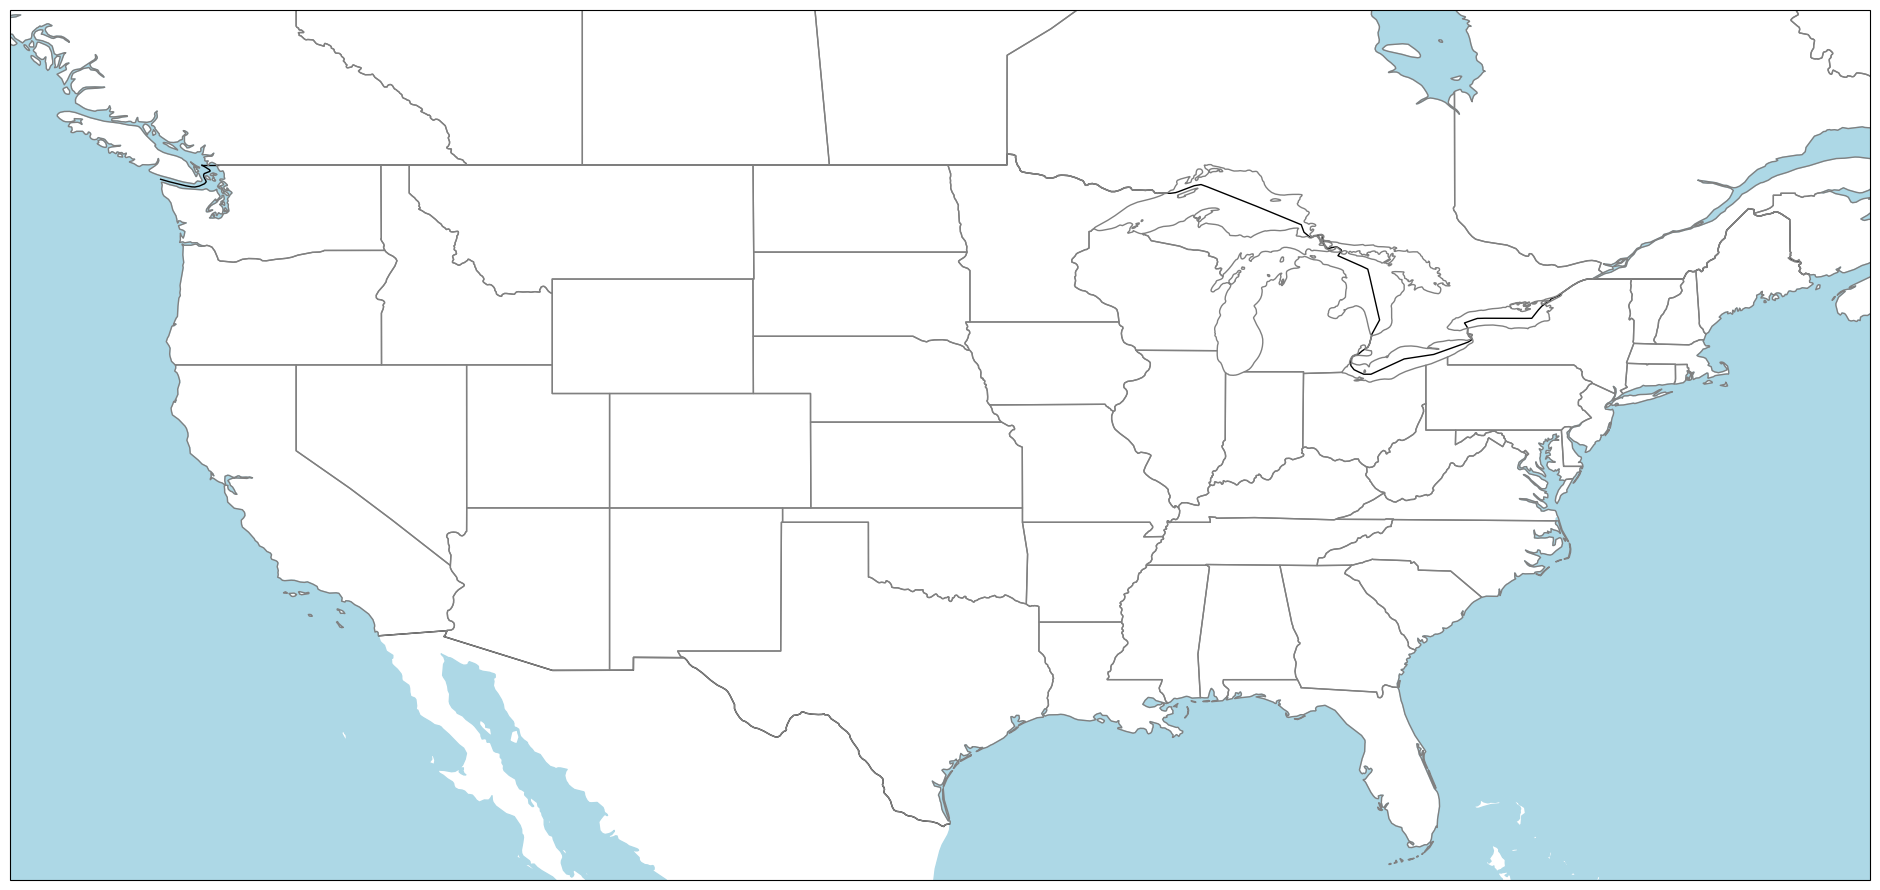

In [3]:
#****MAP OF THE UNITED STATES USING CARTOPY*****

# Imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import requests
import pandas as pd
import io
from herbie import Herbie, FastHerbie 
import pandas as pd, numpy as np 
import xarray as xr
import matplotlib.pyplot as plt
from metpy.plots import colortables
import matplotlib.colors as mcolors

# Create the base map
fig = plt.figure(figsize=(24,18))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-130, -65, 24, 50])  # CONUS
ax.add_feature(cfeature.COASTLINE, edgecolor='lightblue')
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES, edgecolor='gray')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

# Coordinates for every NFL Stadium
Stadiums = {
    'State Farm\nStadium': (33.5276, -112.2626),
    'Mercedes-Benz Stadium': (33.7550, -84.4008),
    'M&T Bank Stadium': (39.2779, -76.6227),
    'HighMark Stadium': (42.7738, -78.7868),
    'Bank of America Stadium': (35.2251, -80.8529),
    'Soldier Field': (41.8623, -87.6167),
    'Paycor Stadium': (39.0954, -84.5160),
    'Huntington Bank Field': (41.5061, -81.6995),
    'AT&T Stadium': (32.7473, -97.0945),
    'Empower Field\nat Mile High': (39.7439, -105.0201),
    'Ford Field': (42.3400, -83.0456),
    'Lambeau Field': (44.5013, -88.0622),
    'NRG Stadium': (29.6847, -95.4107),
    'Lucas Oil Stadium': (39.7601, -86.1639),
    'TIAA Bank Field': (30.3239, -81.6373),
    'GEHA Field at\nArrowhead Stadium': (39.0489, -94.4849),
    'Las Vegas Raiders': (36.0908, -115.1830),
    'SoFi Stadium': (33.9535, -118.3392),
    'Hard Rock Stadium': (25.9580, -80.2389),
    'U.S. Bank Stadium': (44.9738, -93.2575),
    'Gillette Stadium': (42.0909, -71.2643),
    'Caesars\nSuperdome': (29.9511, -90.0812),
    'Metlife Stadium': (40.8135, -74.0745),
    'Lincoln Financial Field': (39.9008, -75.1675),
    'Acrisure Stadium': (40.4468, -80.0158),
    "Levi's Stadium": (37.4030, -121.9700),
    'Lumen Field': (47.5952, -122.3316),
    'Raymond James Stadium': (27.9759, -82.5033),
    'Nissan Stadium': (36.1665, -86.7713),
    'Northwest Field': (38.9078, -76.8644),
}

#Code to load the precipitation from the GFS model 
# Setting the file to a variable
fname = 'PITCLE'
path = f"/home/bds5658/meteo473/sp26_groupwork/473_sp26_group9/data/{fname}.nc"
gamedata = xr.open_dataset(path)
gamedata

#Change the longitude range 
gamedata = gamedata.assign_coords( longitude = (((gamedata.longitude + 180) % 360) - 180))

# Rain Rate 'RPRATE', snow 'SPRATE', Freezing rain 'FPRATE', Ice pellets 'IPRATE'

#Assign variables to the right forecast hour (16)
rain = gamedata['prate'].isel(valid_time=16) * 141.73
snow = gamedata['prate'].isel(valid_time=16) * 141.73 * 10
lat = gamedata['latitude']
lon = gamedata['longitude']

crain = gamedata['crain'].isel(valid_time=16)
csnow = gamedata['csnow'].isel(valid_time=16)

#Mask the zero values 
rain_mask = rain.where(crain >0)
snow_mask = snow.where(csnow >0)


#Rain Intensity color map (got this from AI)
colors = [
    "#00FF00",  # light green
    "#66FF00",
    "#CCFF00",
    "#FFFF00",  # yellow
    "#FFCC00",
    "#FF9900",  # orange
    "#FF4D00",
    "#FF0000",  # red
    "#CC00CC",
    "#8000FF"   # purple
]
rain_cmap = mcolors.LinearSegmentedColormap.from_list("rain_radar", colors)


#Plot the rain onto the map 
rain_plot = ax.pcolormesh(lon, lat, rain_mask, cmap=rain_cmap, shading='auto', alpha=0.55, vmin=0, vmax=0.5, transform=ccrs.PlateCarree())

#Plot the snow onto the map
snow_plot = ax.pcolormesh(lon, lat, snow_mask, cmap='Blues', shading='auto', alpha=0.55, vmin=0, vmax=1, transform=ccrs.PlateCarree())

#Colorbars
cbar_snow = fig.colorbar(snow_plot, ax=ax, orientation='horizontal', pad=0.08, shrink=0.7)
cbar_snow.set_label('Snow Rate (in/hr)')
cbar_rain = fig.colorbar(rain_plot, ax=ax, orientation='horizontal', pad=0.2, shrink=0.7)
cbar_rain.set_label('Rain Rate (in/hr)')

# Plot stadiums last so they show up on top of the precip
for stadium, (lat, lon) in Stadiums.items():
    ax.plot(lon, lat, marker='o', color='black', markersize=8,
            markeredgecolor='white', transform=ccrs.PlateCarree())
    ax.text(lon + 0.5, lat + 0.2, stadium, fontsize=8,
            fontweight='bold', transform=ccrs.PlateCarree())

# Add title
plt.title("NFL Stadiums Precipitation Map", fontsize=20)

#Show the final map
plt.show()

In [2]:
#Plots 



#Create a plot with the ambient temperature data 


#Create a plot with the wind speed data


#Create a plot with the wind direction data 


#Create a plot with the wind speed data


#Create a plot with the rain data 


#Create a plot with the snow data


#Create a plot with the index data
